In [ ]:
pip install open3d torch torchvision scikit-learn numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.6 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 102.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 14.5 MB/s eta 0:00:00
  Attempting uninst

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 22.8 MB/s eta 0:00:0000:01


In [ ]:
import os
import open3d as o3d
import glob

# ROOT_DIR = "/content/drive/MyDrive/Data"
ROOT_DIR = "/kaggle/input/data-rar/data_"
SUPPORTED_EXTENSIONS = ["*.xyz", "*.pts", "*.txt"]

data = []
labels = []
class_names = sorted(os.listdir(ROOT_DIR))

for cls_id, cls_name in enumerate(class_names):
    cls_path = os.path.join(ROOT_DIR, cls_name)
    if not os.path.isdir(cls_path):
        continue

    point_files = []
    for ext in SUPPORTED_EXTENSIONS:
        point_files.extend(glob.glob(os.path.join(cls_path, ext)))

    print(f"{cls_name}: {len(point_files)} fichiers trouvés")

    for file_path in point_files:
        try:
            pc = o3d.io.read_point_cloud(file_path, format='xyz')
            if len(pc.points) > 0:
                data.append(pc)
                labels.append(cls_id)
        except Exception as e:
            print(f"❌ Erreur lecture {file_path} : {str(e)}")

print(f"\n✅ {len(data)} nuages chargés pour {len(class_names)} classes.")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Buche: 164 fichiers trouvés
Douglasie: 183 fichiers trouvés
Eiche: 22 fichiers trouvés
Esche: 39 fichiers trouvés
Fichte: 158 fichiers trouvés
Kiefer: 25 fichiers trouvés
Roteiche: 100 fichiers trouvés

✅ 691 nuages chargés pour 8 classes.


# Population'size= 5 et k(nombre voisin) = 10

Pour exécuter le pipeline:
=== Pipeline Simplifié BFOA + Logique Floue ===

1. Prétraitement des données...
Prétraitement rapide des données...


100%|██████████| 691/691 [00:06<00:00, 102.19it/s]


   Temps: 6.77s
   Shape: (691, 512, 3)

2. Division: Train=483, Val=104, Test=104

3. Entraînement DGCNN...
   Temps d'entraînement: 1.15s

4. Extraction des features DGCNN...

5. Optimisation BFOA + Logique Floue...

   Optimisation SVM...
   Paramètres: {'C': 9.007801246390535, 'gamma': 0.02510614344863906}
   Temps: 1.48s

   Optimisation KNN...
   Paramètres: {'n_neighbors': 14}
   Temps: 0.64s

   Optimisation DT...
   Paramètres: {'max_depth': 13, 'min_samples_split': 12}
   Temps: 1.12s

   Optimisation NN...
   Paramètres: {'hidden_layer_sizes': (85,), 'learning_rate_init': 0.001}
   Temps: 18.28s

6. Évaluation finale...

=== RÉSULTATS ===

Modèles optimisés (BFOA + Logique Floue):
   SVM: 66.35%
   KNN: 59.62%
   DT: 66.35%
   NN: 66.35%

Modèles baseline:
   SVM: 59.62%
   KNN: 55.77%
   DT: 64.42%
   NN: 70.19%

Amélioration:
   SVM: +11.29%
   KNN: +6.90%
   DT: +2.99%
   NN: -5.48%

8. Génération des visualisations...


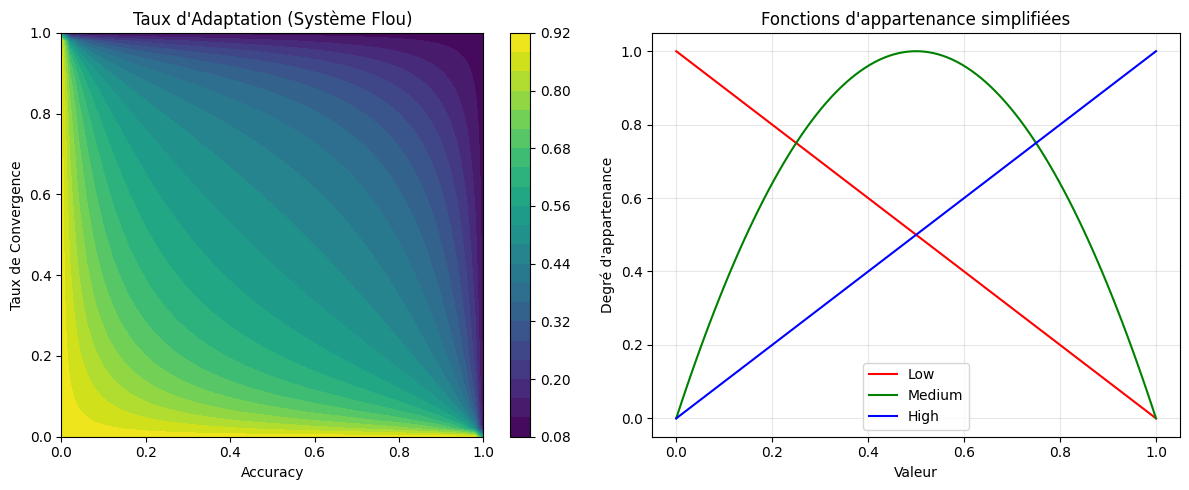

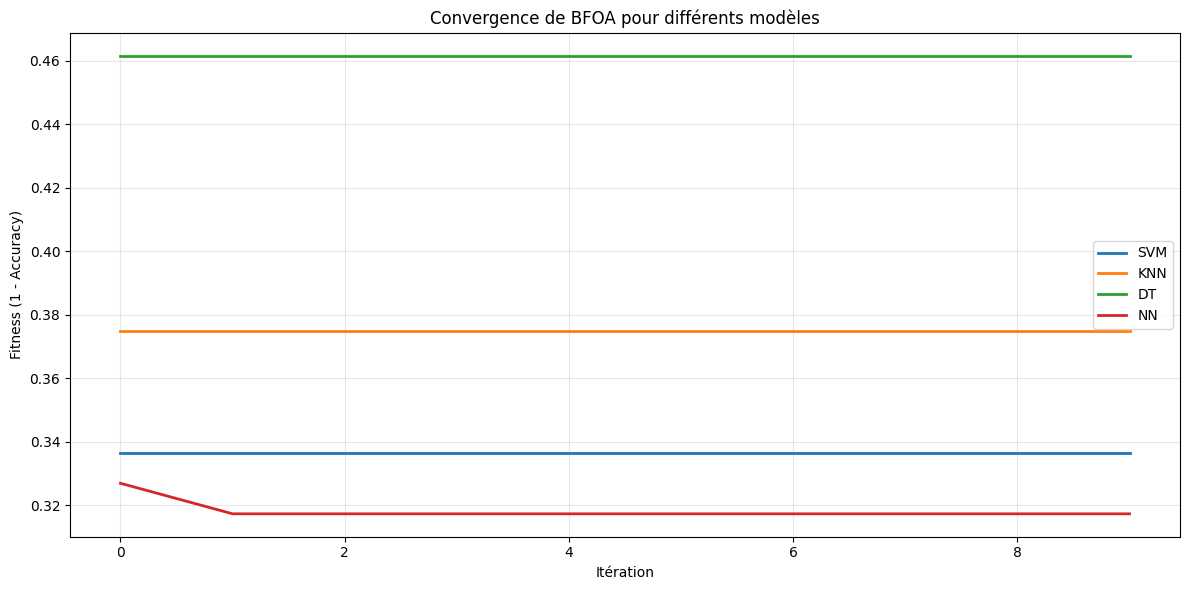

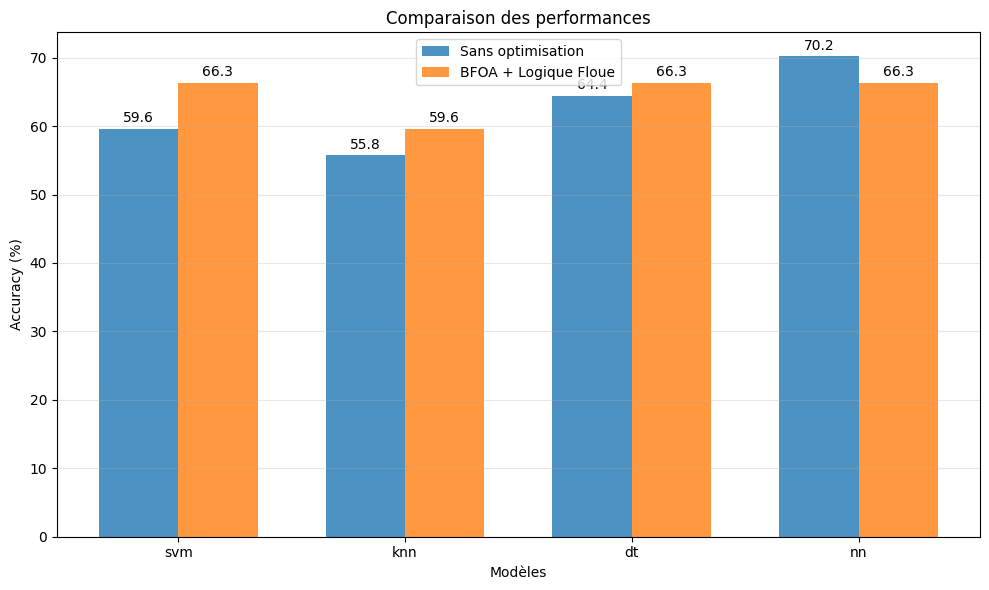

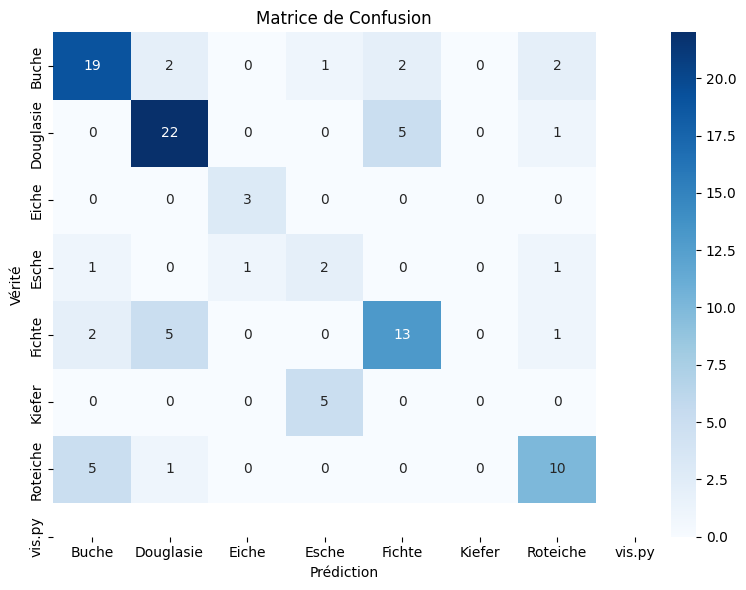

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =====================================================
# 1. PRÉTRAITEMENT
# =====================================================

def subsample_point_cloud(points, n_points=1024):
    """Sous-échantillonne un nuage de points"""
    current_points = len(points)

    if current_points >= n_points:
        indices = np.random.choice(current_points, n_points, replace=False)
        return points[indices]
    else:
        indices = np.random.choice(current_points, n_points, replace=True)
        return points[indices]

def preprocess_data_(data, labels, n_points=512):
    """Version rapide du prétraitement"""
    processed_data = []
    processed_labels = []

    print("Prétraitement rapide des données...")
    for i in tqdm(range(len(data))):
        points = np.asarray(data[i].points)
        if len(points) > 0:
            # Normalisation des points
            points = points - np.mean(points, axis=0)
            points = points / (np.max(np.abs(points)) + 1e-6)

            processed_points = subsample_point_cloud(points, n_points)
            processed_data.append(processed_points)
            processed_labels.append(labels[i])

    return np.array(processed_data), np.array(processed_labels)

# =====================================================
# 2. DGCNN
# =====================================================

class DGCNN(nn.Module):
    """Version simplifiée de DGCNN pour exécution rapide"""
    def __init__(self, k=10, num_classes=7):
        super(DGCNN, self).__init__()
        self.k = k

        # Architecture simplifiée
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 256, 1)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(0.3)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)

    def forward(self, x):
        # x: (batch, points, 3)
        x = x.transpose(2, 1)  # (batch, 3, points)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = F.adaptive_max_pool1d(x, 1).squeeze(2)  # Global max pooling

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        features = F.relu(self.fc2(x))
        x = self.fc3(features)

        return x

    def get_features(self, x):
        """Extraction de features pour les classificateurs"""
        x = x.transpose(2, 1)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = F.adaptive_max_pool1d(x, 1).squeeze(2)

        x = F.relu(self.fc1(x))
        features = F.relu(self.fc2(x))

        return features

# =====================================================
# 3. SYSTÈME FLOU
# =====================================================

class FuzzySystem:
    """Système flou simplifié sans bibliothèque externe"""
    def __init__(self):
        self.rules = [
            # (accuracy_low, conv_slow) -> high adaptation
            (lambda a, c: (1-a) * (1-c), 0.9),
            # (accuracy_medium, conv_medium) -> medium adaptation
            (lambda a, c: 4*a*(1-a) * 4*c*(1-c), 0.5),
            # (accuracy_high, conv_) -> low adaptation
            (lambda a, c: a * c, 0.1),
        ]

    def compute_adaptation_rate(self, accuracy, convergence_rate):
        """Calcul simplifié du taux d'adaptation"""
        total_weight = 0
        weighted_sum = 0

        for rule_func, output in self.rules:
            weight = rule_func(accuracy, convergence_rate)
            total_weight += weight
            weighted_sum += weight * output

        if total_weight > 0:
            return weighted_sum / total_weight
        return 0.5

# =====================================================
# 4. BFOA
# =====================================================

class BFOA:
    """Version simplifiée et rapide de BFOA"""
    def __init__(self, population_size=5, dimensions=2, bounds=None,
                 max_iterations=20, fuzzy_system=None):
        self.population_size = population_size
        self.dimensions = dimensions
        self.bounds = bounds or [(0, 1)] * dimensions
        self.max_iterations = max_iterations
        self.fuzzy_system = fuzzy_system or FuzzySystem()

        # Initialisation
        self.population = np.random.uniform(
            [b[0] for b in self.bounds],
            [b[1] for b in self.bounds],
            (population_size, dimensions)
        )
        self.fitness = np.full(population_size, np.inf)
        self.best_position = None
        self.best_fitness = np.inf
        self.history = []

    def evaluate_population(self, eval_func):
        """Évaluation parallèle de la population"""
        for i in range(self.population_size):
            self.fitness[i] = eval_func(self.population[i])

        # Mise à jour du meilleur
        min_idx = np.argmin(self.fitness)
        if self.fitness[min_idx] < self.best_fitness:
            self.best_fitness = self.fitness[min_idx]
            self.best_position = self.population[min_idx].copy()

        self.history.append(self.best_fitness)

    def optimize(self, eval_func):
        """Optimisation simplifiée"""
        step_size = 0.1

        for iteration in range(self.max_iterations):
            # Évaluation
            self.evaluate_population(eval_func)

            # Chemotaxis simplifié
            for i in range(self.population_size):
                # Mouvement aléatoire
                direction = np.random.randn(self.dimensions)
                direction = direction / (np.linalg.norm(direction) + 1e-8)

                # Nouveau position
                new_pos = self.population[i] + step_size * direction
                new_pos = np.clip(new_pos, [b[0] for b in self.bounds],
                                           [b[1] for b in self.bounds])

                # Évaluation
                new_fitness = eval_func(new_pos)

                # Mise à jour si amélioration
                if new_fitness < self.fitness[i]:
                    self.population[i] = new_pos
                    self.fitness[i] = new_fitness

            # Adaptation du pas avec logique floue
            if len(self.history) > 2:
                accuracy = 1 - self.best_fitness
                convergence = abs(self.history[-2] - self.history[-1])
                step_size = 0.1 * self.fuzzy_system.compute_adaptation_rate(accuracy, convergence)

        return self.best_position, self.best_fitness

# =====================================================
# 5. OPTIMISATION  DES HYPERPARAMÈTRES
# =====================================================

def optimize_hyperparameters_(X_train, y_train, X_val, y_val, model_type='svm'):
    """Optimisation rapide des hyperparamètres"""
    fuzzy_system = FuzzySystem()

    if model_type == 'svm':
        # Bounds réduites pour SVM
        bounds = [(0.1, 10), (0.001, 0.1)]  # C, gamma
        def eval_func(params):
            C, gamma = params
            clf = SVC(C=C, gamma=gamma, kernel='rbf', max_iter=100)
            clf.fit(X_train[:500], y_train[:500])  # Sous-échantillon pour rapidité
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=5, dimensions=2, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'C': best_params[0], 'gamma': best_params[1]}, bfoa.history

    elif model_type == 'knn':
        bounds = [(3, 20)]  # k

        def eval_func(params):
            k = int(params[0])
            clf = KNeighborsClassifier(n_neighbors=k)
            clf.fit(X_train[:500], y_train[:500])
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=5, dimensions=1, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'n_neighbors': int(best_params[0])}, bfoa.history

    elif model_type == 'dt':
        bounds = [(3, 20), (3, 20)]   # max_depth, min_samples_split

        def eval_func(params):
            max_depth, min_samples = int(params[0]), int(params[1])
            clf = DecisionTreeClassifier(max_depth=max_depth,
                                       min_samples_split=min_samples,
                                       random_state=42)
            clf.fit(X_train[:500], y_train[:500])
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=5, dimensions=2, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'max_depth': int(best_params[0]),
                'min_samples_split': int(best_params[1])}, bfoa.history

    elif model_type == 'nn':
        bounds = [(10, 100), (0.001, 0.01)] #hidden_size, learning_rate

        def eval_func(params):
            hidden_size, lr = int(params[0]), params[1]
            clf = MLPClassifier(hidden_layer_sizes=(hidden_size,),
                              learning_rate_init=lr,
                              max_iter=100, random_state=42)
            clf.fit(X_train[:500], y_train[:500])
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=5, dimensions=2, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'hidden_layer_sizes': (int(best_params[0]),),
                'learning_rate_init': best_params[1]}, bfoa.history

# =====================================================
# 6. VISUALISATIONS
# =====================================================

def plot_optimization_process(histories, model_names):
    """Visualise le processus d'optimisation BFOA"""
    plt.figure(figsize=(12, 6))

    for i, (history, name) in enumerate(zip(histories, model_names)):
        plt.plot(history, label=f'{name}', linewidth=2)

    plt.xlabel('Itération')
    plt.ylabel('Fitness (1 - Accuracy)')
    plt.title('Convergence de BFOA pour différents modèles')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_fuzzy_system():
    """Visualise le système flou"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Surface de décision du système flou
    accuracy = np.linspace(0, 1, 50)
    convergence = np.linspace(0, 1, 50)
    A, C = np.meshgrid(accuracy, convergence)

    fuzzy_sys = FuzzySystem()
    Z = np.zeros_like(A)

    for i in range(50):
        for j in range(50):
            Z[i, j] = fuzzy_sys.compute_adaptation_rate(A[i, j], C[i, j])

    # Graphique 3D
    contour = ax1.contourf(A, C, Z, levels=20, cmap='viridis')
    ax1.set_xlabel('Accuracy')
    ax1.set_ylabel('Taux de Convergence')
    ax1.set_title('Taux d\'Adaptation (Système Flou)')
    plt.colorbar(contour, ax=ax1)

    # Courbes de membership
    x = np.linspace(0, 1, 100)
    ax2.plot(x, 1-x, label='Low', color='red')
    ax2.plot(x, 4*x*(1-x), label='Medium', color='green')
    ax2.plot(x, x, label='High', color='blue')
    ax2.set_xlabel('Valeur')
    ax2.set_ylabel('Degré d\'appartenance')
    ax2.set_title('Fonctions d\'appartenance simplifiées')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_results_comparison(results_optimized, results_baseline):
    """Compare les résultats optimisés vs baseline"""
    models = list(results_baseline.keys())
    baseline_acc = [results_baseline[m] * 100 for m in models]
    optimized_acc = [results_optimized[m] * 100 for m in models]

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, baseline_acc, width, label='Sans optimisation', alpha=0.8)
    plt.bar(x + width/2, optimized_acc, width, label='BFOA + Logique Floue', alpha=0.8)

    plt.xlabel('Modèles')
    plt.ylabel('Accuracy (%)')
    plt.title('Comparaison des performances')
    plt.xticks(x, models)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

    # Ajouter les valeurs
    for i, (b, o) in enumerate(zip(baseline_acc, optimized_acc)):
        plt.text(i - width/2, b + 0.5, f'{b:.1f}', ha='center', va='bottom')
        plt.text(i + width/2, o + 0.5, f'{o:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Affiche la matrice de confusion"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité')
    plt.title('Matrice de Confusion')
    plt.tight_layout()
    plt.show()

# =====================================================
# 7. PIPELINE PRINCIPAL SIMPLIFIÉ
# =====================================================

def main(data, labels, class_names):
    """Pipeline principal optimisé pour rapidité"""
    print("=== Pipeline Simplifié BFOA + Logique Floue ===\n")

    # 1. Prétraitement
    print("1. Prétraitement des données...")
    start_time = time.time()
    X, y = preprocess_data_(data, labels, n_points=512)
    print(f"   Temps: {time.time() - start_time:.2f}s")
    print(f"   Shape: {X.shape}")

    # 2. Division des données
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    print(f"\n2. Division: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

    # 3. Entraînement DGCNN simplifié
    print("\n3. Entraînement DGCNN...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Conversion en tenseurs
    train_data = torch.FloatTensor(X_train)
    train_labels = torch.LongTensor(y_train)
    test_data = torch.FloatTensor(X_test)
    test_labels = torch.LongTensor(y_test)

    # DataLoaders
    train_dataset = TensorDataset(train_data, train_labels)
    test_dataset = TensorDataset(test_data, test_labels)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    # Modèle
    model = DGCNN(k=20, num_classes=len(class_names)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Entraînement rapide
    start_time = time.time()
    model.train()
    for epoch in range(10):  # Seulement 10 epochs
        for batch_data, batch_labels in train_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

    print(f"   Temps d'entraînement: {time.time() - start_time:.2f}s")

    # 4. Extraction des features
    print("\n4. Extraction des features DGCNN...")
    model.eval()
    with torch.no_grad():
        train_features = model.get_features(train_data.to(device)).cpu().numpy()
        val_features = model.get_features(torch.FloatTensor(X_val).to(device)).cpu().numpy()
        test_features = model.get_features(test_data.to(device)).cpu().numpy()

    # 5. Optimisation des hyperparamètres
    print("\n5. Optimisation BFOA + Logique Floue...")
    models_to_optimize = ['svm', 'knn', 'dt', 'nn']
    optimized_params = {}
    optimization_histories = []

    for model_name in models_to_optimize:
        print(f"\n   Optimisation {model_name.upper()}...")
        start_time = time.time()
        params, history = optimize_hyperparameters_(
            train_features, y_train, val_features, y_val, model_name
        )
        optimized_params[model_name] = params
        optimization_histories.append(history)
        print(f"   Paramètres: {params}")
        print(f"   Temps: {time.time() - start_time:.2f}s")

    # 6. Entraînement et évaluation finale
    print("\n6. Évaluation finale...")
    results_optimized = {}
    results_baseline = {}

    # Modèles optimisés
    models_opt = {
        'svm': SVC(**optimized_params['svm'], kernel='rbf'),
        'knn': KNeighborsClassifier(**optimized_params['knn']),
        'dt': DecisionTreeClassifier(**optimized_params['dt'], random_state=42),
        'nn': MLPClassifier(**optimized_params['nn'], max_iter=200, random_state=42)
    }

    # Modèles baseline
    models_base = {
        'svm': SVC(kernel='rbf'),
        'knn': KNeighborsClassifier(),
        'dt': DecisionTreeClassifier(random_state=42),
        'nn': MLPClassifier(max_iter=200, random_state=42)
    }

    for name in models_opt:
        # Optimisé
        models_opt[name].fit(train_features, y_train)
        pred_opt = models_opt[name].predict(test_features)
        results_optimized[name] = accuracy_score(y_test, pred_opt)

        # Baseline
        models_base[name].fit(train_features, y_train)
        pred_base = models_base[name].predict(test_features)
        results_baseline[name] = accuracy_score(y_test, pred_base)

    # 7. Affichage des résultats
    print("\n=== RÉSULTATS ===")
    print("\nModèles optimisés (BFOA + Logique Floue):")
    for name, acc in results_optimized.items():
        print(f"   {name.upper()}: {acc*100:.2f}%")

    print("\nModèles baseline:")
    for name, acc in results_baseline.items():
        print(f"   {name.upper()}: {acc*100:.2f}%")

    print("\nAmélioration:")
    for name in results_optimized:
        improvement = (results_optimized[name] - results_baseline[name]) / results_baseline[name] * 100
        print(f"   {name.upper()}: {improvement:+.2f}%")

    # 8. Visualisations
    print("\n8. Génération des visualisations...")

    # Système flou
    plot_fuzzy_system()

    # Processus d'optimisation
    plot_optimization_process(optimization_histories, [m.upper() for m in models_to_optimize])

    # Comparaison des résultats
    plot_results_comparison(results_optimized, results_baseline)

    # Matrice de confusion pour le meilleur modèle
    best_model_name = max(results_optimized, key=results_optimized.get)
    best_predictions = models_opt[best_model_name].predict(test_features)
    plot_confusion_matrix(y_test, best_predictions, class_names)

    return results_optimized, results_baseline, optimized_params

# =====================================================
# UTILISATION
# =====================================================

if __name__ == "__main__":
    # Exemple d'utilisation
    print("Pour exécuter le pipeline:")
    results_opt, results_base, params = main(data, labels, class_names)


# Avec taille de la population à 30 et k=20(nombre de voisin pour DGCNN)

Pour exécuter le pipeline:
=== Pipeline Simplifié BFOA + Logique Floue ===

1. Prétraitement des données...
Prétraitement rapide des données...


100%|██████████| 691/691 [00:06<00:00, 99.65it/s] 


   Temps: 6.94s
   Shape: (691, 512, 3)

2. Division: Train=483, Val=104, Test=104

3. Entraînement DGCNN...
   Temps d'entraînement: 0.56s

4. Extraction des features DGCNN...

5. Optimisation BFOA + Logique Floue...

   Optimisation SVM...
   Paramètres: {'C': 8.350674723253542, 'gamma': 0.06642398398032762}
   Temps: 8.95s

   Optimisation KNN...
   Paramètres: {'n_neighbors': 18}
   Temps: 3.71s

   Optimisation DT...
   Paramètres: {'max_depth': 4, 'min_samples_split': 15}
   Temps: 6.07s

   Optimisation NN...
   Paramètres: {'hidden_layer_sizes': (95,), 'learning_rate_init': 0.00345332761538895}
   Temps: 109.51s

6. Évaluation finale...

=== RÉSULTATS ===

Modèles optimisés (BFOA + Logique Floue):
   SVM: 57.69%
   KNN: 60.58%
   DT: 54.81%
   NN: 55.77%

Modèles baseline:
   SVM: 56.73%
   KNN: 48.08%
   DT: 49.04%
   NN: 56.73%

Amélioration:
   SVM: +1.69%
   KNN: +26.00%
   DT: +11.76%
   NN: -1.69%

8. Génération des visualisations...


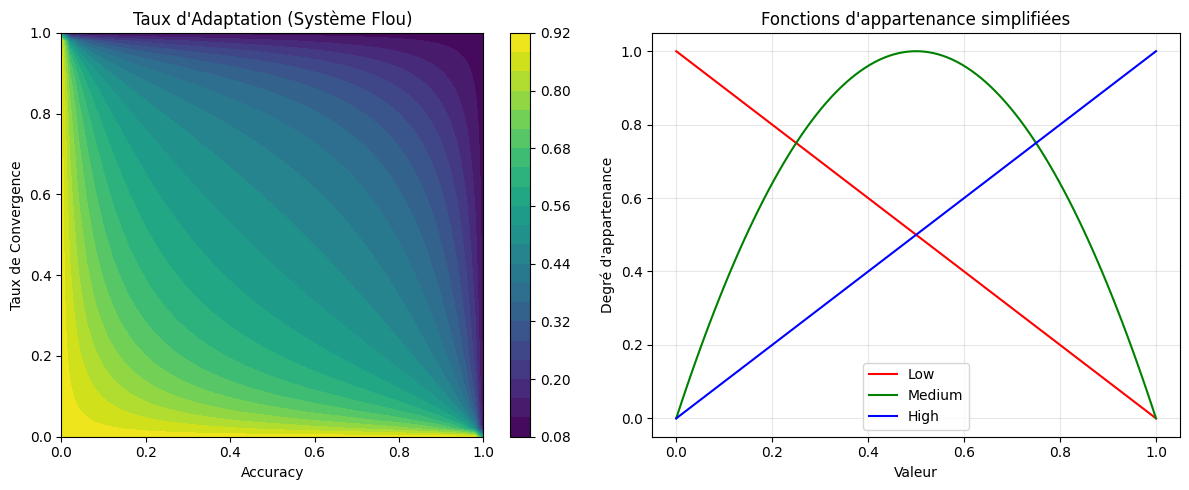

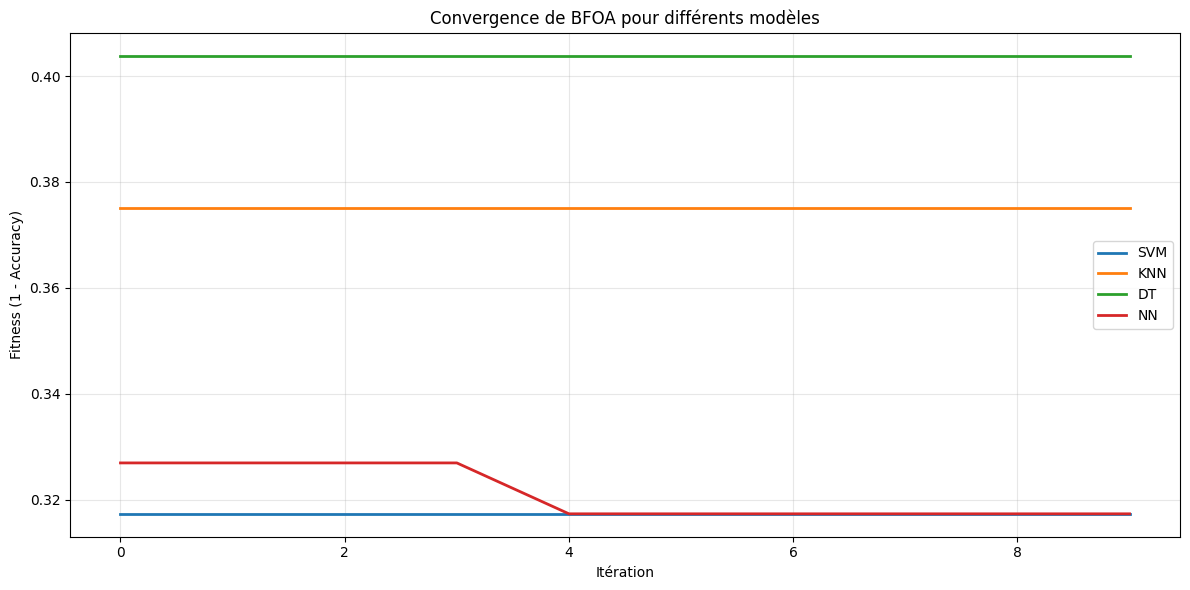

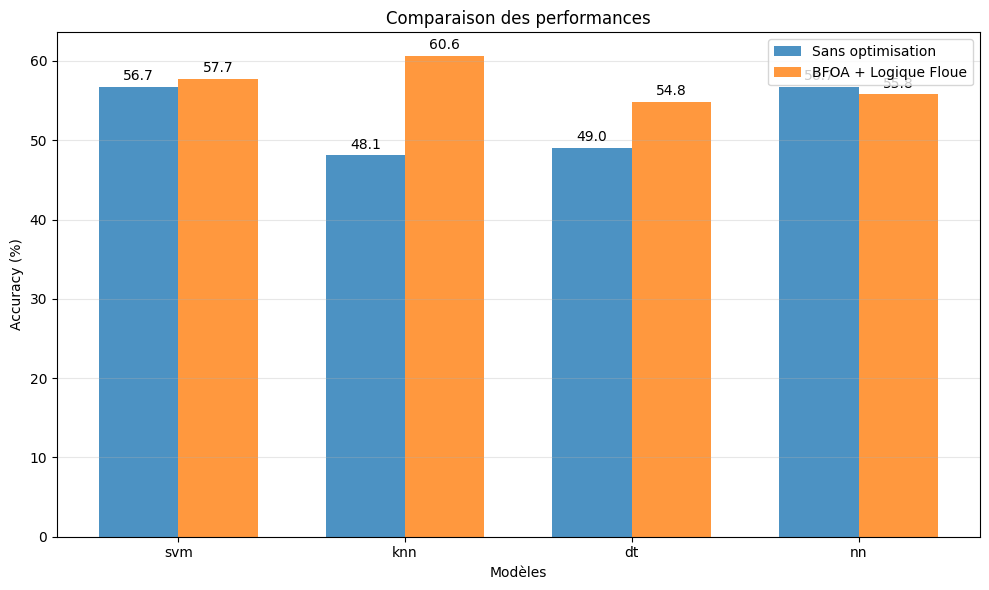

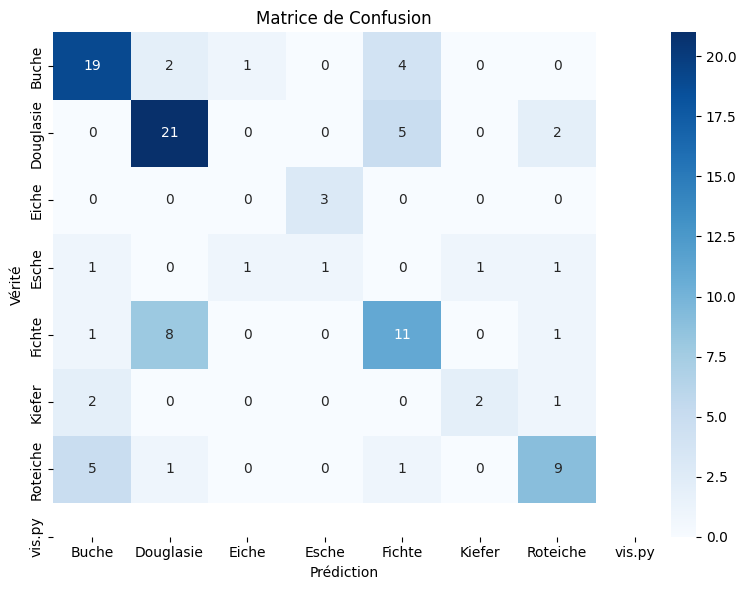

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =====================================================
# 1. PRÉTRAITEMENT
# =====================================================

def subsample_point_cloud(points, n_points=1024):
    """Sous-échantillonne un nuage de points"""
    current_points = len(points)

    if current_points >= n_points:
        indices = np.random.choice(current_points, n_points, replace=False)
        return points[indices]
    else:
        indices = np.random.choice(current_points, n_points, replace=True)
        return points[indices]

def preprocess_data_(data, labels, n_points=512):
    """Version rapide du prétraitement"""
    processed_data = []
    processed_labels = []

    print("Prétraitement rapide des données...")
    for i in tqdm(range(len(data))):
        points = np.asarray(data[i].points)
        if len(points) > 0:
            # Normalisation des points
            points = points - np.mean(points, axis=0)
            points = points / (np.max(np.abs(points)) + 1e-6)

            processed_points = subsample_point_cloud(points, n_points)
            processed_data.append(processed_points)
            processed_labels.append(labels[i])

    return np.array(processed_data), np.array(processed_labels)

# =====================================================
# 2. DGCNN
# =====================================================

class DGCNN(nn.Module):
    """Version simplifiée de DGCNN pour exécution rapide"""
    def __init__(self, k=20, num_classes=7):
        super(DGCNN, self).__init__()
        self.k = k

        # Architecture simplifiée
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 256, 1)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(0.3)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)

    def forward(self, x):
        # x: (batch, points, 3)
        x = x.transpose(2, 1)  # (batch, 3, points)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = F.adaptive_max_pool1d(x, 1).squeeze(2)  # Global max pooling

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        features = F.relu(self.fc2(x))
        x = self.fc3(features)

        return x

    def get_features(self, x):
        """Extraction de features pour les classificateurs"""
        x = x.transpose(2, 1)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = F.adaptive_max_pool1d(x, 1).squeeze(2)

        x = F.relu(self.fc1(x))
        features = F.relu(self.fc2(x))

        return features

# =====================================================
# 3. SYSTÈME FLOU
# =====================================================

class FuzzySystem:
    """Système flou simplifié sans bibliothèque externe"""
    def __init__(self):
        self.rules = [
            # (accuracy_low, conv_slow) -> high adaptation
            (lambda a, c: (1-a) * (1-c), 0.9),
            # (accuracy_medium, conv_medium) -> medium adaptation
            (lambda a, c: 4*a*(1-a) * 4*c*(1-c), 0.5),
            # (accuracy_high, conv_) -> low adaptation
            (lambda a, c: a * c, 0.1),
        ]

    def compute_adaptation_rate(self, accuracy, convergence_rate):
        """Calcul simplifié du taux d'adaptation"""
        total_weight = 0
        weighted_sum = 0

        for rule_func, output in self.rules:
            weight = rule_func(accuracy, convergence_rate)
            total_weight += weight
            weighted_sum += weight * output

        if total_weight > 0:
            return weighted_sum / total_weight
        return 0.5

# =====================================================
# 4. BFOA
# =====================================================

class BFOA:
    """Version simplifiée et rapide de BFOA"""
    def __init__(self, population_size=30, dimensions=2, bounds=None,
                 max_iterations=20, fuzzy_system=None):
        self.population_size = population_size
        self.dimensions = dimensions
        self.bounds = bounds or [(0, 1)] * dimensions
        self.max_iterations = max_iterations
        self.fuzzy_system = fuzzy_system or FuzzySystem()

        # Initialisation
        self.population = np.random.uniform(
            [b[0] for b in self.bounds],
            [b[1] for b in self.bounds],
            (population_size, dimensions)
        )
        self.fitness = np.full(population_size, np.inf)
        self.best_position = None
        self.best_fitness = np.inf
        self.history = []

    def evaluate_population(self, eval_func):
        """Évaluation parallèle de la population"""
        for i in range(self.population_size):
            self.fitness[i] = eval_func(self.population[i])

        # Mise à jour du meilleur
        min_idx = np.argmin(self.fitness)
        if self.fitness[min_idx] < self.best_fitness:
            self.best_fitness = self.fitness[min_idx]
            self.best_position = self.population[min_idx].copy()

        self.history.append(self.best_fitness)

    def optimize(self, eval_func):
        """Optimisation simplifiée"""
        step_size = 0.1

        for iteration in range(self.max_iterations):
            # Évaluation
            self.evaluate_population(eval_func)

            # Chemotaxis simplifié
            for i in range(self.population_size):
                # Mouvement aléatoire
                direction = np.random.randn(self.dimensions)
                direction = direction / (np.linalg.norm(direction) + 1e-8)

                # Nouveau position
                new_pos = self.population[i] + step_size * direction
                new_pos = np.clip(new_pos, [b[0] for b in self.bounds],
                                           [b[1] for b in self.bounds])

                # Évaluation
                new_fitness = eval_func(new_pos)

                # Mise à jour si amélioration
                if new_fitness < self.fitness[i]:
                    self.population[i] = new_pos
                    self.fitness[i] = new_fitness

            # Adaptation du pas avec logique floue
            if len(self.history) > 2:
                accuracy = 1 - self.best_fitness
                convergence = abs(self.history[-2] - self.history[-1])
                step_size = 0.1 * self.fuzzy_system.compute_adaptation_rate(accuracy, convergence)

        return self.best_position, self.best_fitness

# =====================================================
# 5. OPTIMISATION  DES HYPERPARAMÈTRES
# =====================================================

def optimize_hyperparameters_(X_train, y_train, X_val, y_val, model_type='svm'):
    """Optimisation rapide des hyperparamètres"""
    fuzzy_system = FuzzySystem()

    if model_type == 'svm':
        # Bounds réduites pour SVM
        bounds = [(0.1, 10), (0.001, 0.1)]  # C, gamma
        def eval_func(params):
            C, gamma = params
            clf = SVC(C=C, gamma=gamma, kernel='rbf', max_iter=100)
            clf.fit(X_train[:500], y_train[:500])  # Sous-échantillon pour rapidité
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=30, dimensions=2, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'C': best_params[0], 'gamma': best_params[1]}, bfoa.history

    elif model_type == 'knn':
        bounds = [(3, 40)]  # k

        def eval_func(params):
            k = int(params[0])
            clf = KNeighborsClassifier(n_neighbors=k)
            clf.fit(X_train[:500], y_train[:500])
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=30, dimensions=1, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'n_neighbors': int(best_params[0])}, bfoa.history

    elif model_type == 'dt':
        bounds = [(3, 20), (3, 20)]   # max_depth, min_samples_split

        def eval_func(params):
            max_depth, min_samples = int(params[0]), int(params[1])
            clf = DecisionTreeClassifier(max_depth=max_depth,
                                       min_samples_split=min_samples,
                                       random_state=42)
            clf.fit(X_train[:500], y_train[:500])
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=30, dimensions=2, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'max_depth': int(best_params[0]),
                'min_samples_split': int(best_params[1])}, bfoa.history

    elif model_type == 'nn':
        bounds = [(10, 100), (0.001, 0.01)] #hidden_size, learning_rate

        def eval_func(params):
            hidden_size, lr = int(params[0]), params[1]
            clf = MLPClassifier(hidden_layer_sizes=(hidden_size,),
                              learning_rate_init=lr,
                              max_iter=100, random_state=42)
            clf.fit(X_train[:500], y_train[:500])
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=30, dimensions=2, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'hidden_layer_sizes': (int(best_params[0]),),
                'learning_rate_init': best_params[1]}, bfoa.history

# =====================================================
# 6. VISUALISATIONS
# =====================================================

def plot_optimization_process(histories, model_names):
    """Visualise le processus d'optimisation BFOA"""
    plt.figure(figsize=(12, 6))

    for i, (history, name) in enumerate(zip(histories, model_names)):
        plt.plot(history, label=f'{name}', linewidth=2)

    plt.xlabel('Itération')
    plt.ylabel('Fitness (1 - Accuracy)')
    plt.title('Convergence de BFOA pour différents modèles')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_fuzzy_system():
    """Visualise le système flou"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Surface de décision du système flou
    accuracy = np.linspace(0, 1, 50)
    convergence = np.linspace(0, 1, 50)
    A, C = np.meshgrid(accuracy, convergence)

    fuzzy_sys = FuzzySystem()
    Z = np.zeros_like(A)

    for i in range(50):
        for j in range(50):
            Z[i, j] = fuzzy_sys.compute_adaptation_rate(A[i, j], C[i, j])

    # Graphique 3D
    contour = ax1.contourf(A, C, Z, levels=20, cmap='viridis')
    ax1.set_xlabel('Accuracy')
    ax1.set_ylabel('Taux de Convergence')
    ax1.set_title('Taux d\'Adaptation (Système Flou)')
    plt.colorbar(contour, ax=ax1)

    # Courbes de membership
    x = np.linspace(0, 1, 100)
    ax2.plot(x, 1-x, label='Low', color='red')
    ax2.plot(x, 4*x*(1-x), label='Medium', color='green')
    ax2.plot(x, x, label='High', color='blue')
    ax2.set_xlabel('Valeur')
    ax2.set_ylabel('Degré d\'appartenance')
    ax2.set_title('Fonctions d\'appartenance simplifiées')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_results_comparison(results_optimized, results_baseline):
    """Compare les résultats optimisés vs baseline"""
    models = list(results_baseline.keys())
    baseline_acc = [results_baseline[m] * 100 for m in models]
    optimized_acc = [results_optimized[m] * 100 for m in models]

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, baseline_acc, width, label='Sans optimisation', alpha=0.8)
    plt.bar(x + width/2, optimized_acc, width, label='BFOA + Logique Floue', alpha=0.8)

    plt.xlabel('Modèles')
    plt.ylabel('Accuracy (%)')
    plt.title('Comparaison des performances')
    plt.xticks(x, models)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

    # Ajouter les valeurs
    for i, (b, o) in enumerate(zip(baseline_acc, optimized_acc)):
        plt.text(i - width/2, b + 0.5, f'{b:.1f}', ha='center', va='bottom')
        plt.text(i + width/2, o + 0.5, f'{o:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Affiche la matrice de confusion"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité')
    plt.title('Matrice de Confusion')
    plt.tight_layout()
    plt.show()

# =====================================================
# 7. PIPELINE PRINCIPAL SIMPLIFIÉ
# =====================================================

def main(data, labels, class_names):
    """Pipeline principal optimisé pour rapidité"""
    print("=== Pipeline Simplifié BFOA + Logique Floue ===\n")

    # 1. Prétraitement
    print("1. Prétraitement des données...")
    start_time = time.time()
    X, y = preprocess_data_(data, labels, n_points=512)
    print(f"   Temps: {time.time() - start_time:.2f}s")
    print(f"   Shape: {X.shape}")

    # 2. Division des données
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    print(f"\n2. Division: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

    # 3. Entraînement DGCNN simplifié
    print("\n3. Entraînement DGCNN...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Conversion en tenseurs
    train_data = torch.FloatTensor(X_train)
    train_labels = torch.LongTensor(y_train)
    test_data = torch.FloatTensor(X_test)
    test_labels = torch.LongTensor(y_test)

    # DataLoaders
    train_dataset = TensorDataset(train_data, train_labels)
    test_dataset = TensorDataset(test_data, test_labels)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    # Modèle
    model = DGCNN(k=20, num_classes=len(class_names)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Entraînement rapide
    start_time = time.time()
    model.train()
    for epoch in range(10):  # Seulement 10 epochs
        for batch_data, batch_labels in train_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

    print(f"   Temps d'entraînement: {time.time() - start_time:.2f}s")

    # 4. Extraction des features
    print("\n4. Extraction des features DGCNN...")
    model.eval()
    with torch.no_grad():
        train_features = model.get_features(train_data.to(device)).cpu().numpy()
        val_features = model.get_features(torch.FloatTensor(X_val).to(device)).cpu().numpy()
        test_features = model.get_features(test_data.to(device)).cpu().numpy()

    # 5. Optimisation des hyperparamètres
    print("\n5. Optimisation BFOA + Logique Floue...")
    models_to_optimize = ['svm', 'knn', 'dt', 'nn']
    optimized_params = {}
    optimization_histories = []

    for model_name in models_to_optimize:
        print(f"\n   Optimisation {model_name.upper()}...")
        start_time = time.time()
        params, history = optimize_hyperparameters_(
            train_features, y_train, val_features, y_val, model_name
        )
        optimized_params[model_name] = params
        optimization_histories.append(history)
        print(f"   Paramètres: {params}")
        print(f"   Temps: {time.time() - start_time:.2f}s")

    # 6. Entraînement et évaluation finale
    print("\n6. Évaluation finale...")
    results_optimized = {}
    results_baseline = {}

    # Modèles optimisés
    models_opt = {
        'svm': SVC(**optimized_params['svm'], kernel='rbf'),
        'knn': KNeighborsClassifier(**optimized_params['knn']),
        'dt': DecisionTreeClassifier(**optimized_params['dt'], random_state=42),
        'nn': MLPClassifier(**optimized_params['nn'], max_iter=200, random_state=42)
    }

    # Modèles baseline
    models_base = {
        'svm': SVC(kernel='rbf'),
        'knn': KNeighborsClassifier(),
        'dt': DecisionTreeClassifier(random_state=42),
        'nn': MLPClassifier(max_iter=200, random_state=42)
    }

    for name in models_opt:
        # Optimisé
        models_opt[name].fit(train_features, y_train)
        pred_opt = models_opt[name].predict(test_features)
        results_optimized[name] = accuracy_score(y_test, pred_opt)

        # Baseline
        models_base[name].fit(train_features, y_train)
        pred_base = models_base[name].predict(test_features)
        results_baseline[name] = accuracy_score(y_test, pred_base)

    # 7. Affichage des résultats
    print("\n=== RÉSULTATS ===")
    print("\nModèles optimisés (BFOA + Logique Floue):")
    for name, acc in results_optimized.items():
        print(f"   {name.upper()}: {acc*100:.2f}%")

    print("\nModèles baseline:")
    for name, acc in results_baseline.items():
        print(f"   {name.upper()}: {acc*100:.2f}%")

    print("\nAmélioration:")
    for name in results_optimized:
        improvement = (results_optimized[name] - results_baseline[name]) / results_baseline[name] * 100
        print(f"   {name.upper()}: {improvement:+.2f}%")

    # 8. Visualisations
    print("\n8. Génération des visualisations...")

    # Système flou
    plot_fuzzy_system()

    # Processus d'optimisation
    plot_optimization_process(optimization_histories, [m.upper() for m in models_to_optimize])

    # Comparaison des résultats
    plot_results_comparison(results_optimized, results_baseline)

    # Matrice de confusion pour le meilleur modèle
    best_model_name = max(results_optimized, key=results_optimized.get)
    best_predictions = models_opt[best_model_name].predict(test_features)
    plot_confusion_matrix(y_test, best_predictions, class_names)

    return results_optimized, results_baseline, optimized_params

# =====================================================
# UTILISATION
# =====================================================

if __name__ == "__main__":
    # Exemple d'utilisation
    print("Pour exécuter le pipeline:")
    results_opt, results_base, params = main(data, labels, class_names)


# Avec 20 epochs

Pour exécuter le pipeline:
=== Pipeline Simplifié BFOA + Logique Floue ===

1. Prétraitement des données...
Prétraitement rapide des données...


100%|██████████| 691/691 [00:06<00:00, 102.28it/s]


   Temps: 6.76s
   Shape: (691, 512, 3)

2. Division: Train=483, Val=104, Test=104

3. Entraînement DGCNN...
   Temps d'entraînement: 1.10s

4. Extraction des features DGCNN...

5. Optimisation BFOA + Logique Floue...

   Optimisation SVM...
   Paramètres: {'C': 8.629908116915336, 'gamma': 0.0023254651085991423}
   Temps: 8.88s

   Optimisation KNN...
   Paramètres: {'n_neighbors': 6}
   Temps: 3.78s

   Optimisation DT...
   Paramètres: {'max_depth': 3, 'min_samples_split': 19}
   Temps: 5.42s

   Optimisation NN...
   Paramètres: {'hidden_layer_sizes': (26,), 'learning_rate_init': 0.009346329137211007}
   Temps: 111.59s

6. Évaluation finale...

=== RÉSULTATS ===

Modèles optimisés (BFOA + Logique Floue):
   SVM: 56.73%
   KNN: 53.85%
   DT: 50.00%
   NN: 56.73%

Modèles baseline:
   SVM: 59.62%
   KNN: 54.81%
   DT: 50.00%
   NN: 57.69%

Amélioration:
   SVM: -4.84%
   KNN: -1.75%
   DT: +0.00%
   NN: -1.67%

8. Génération des visualisations...


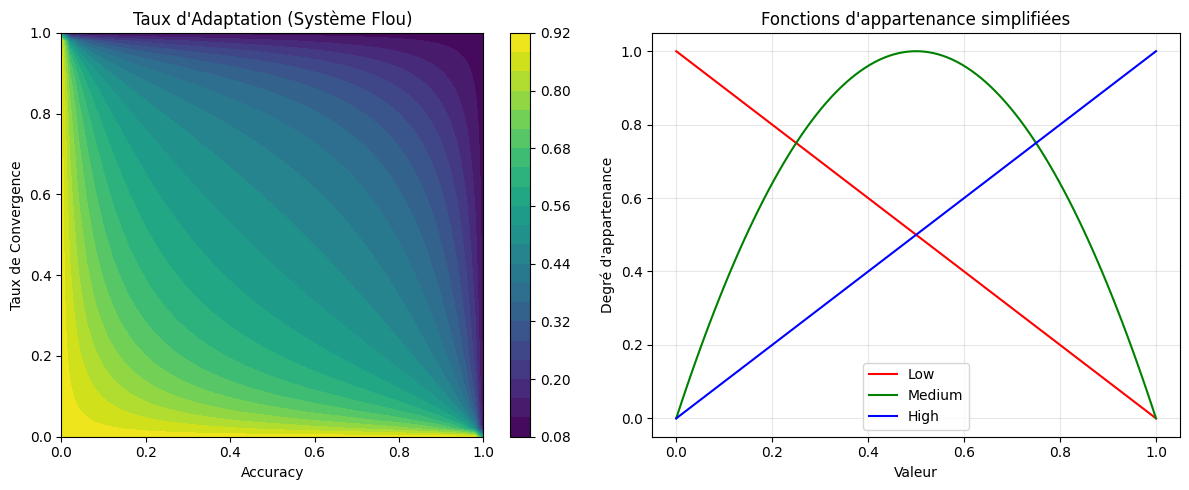

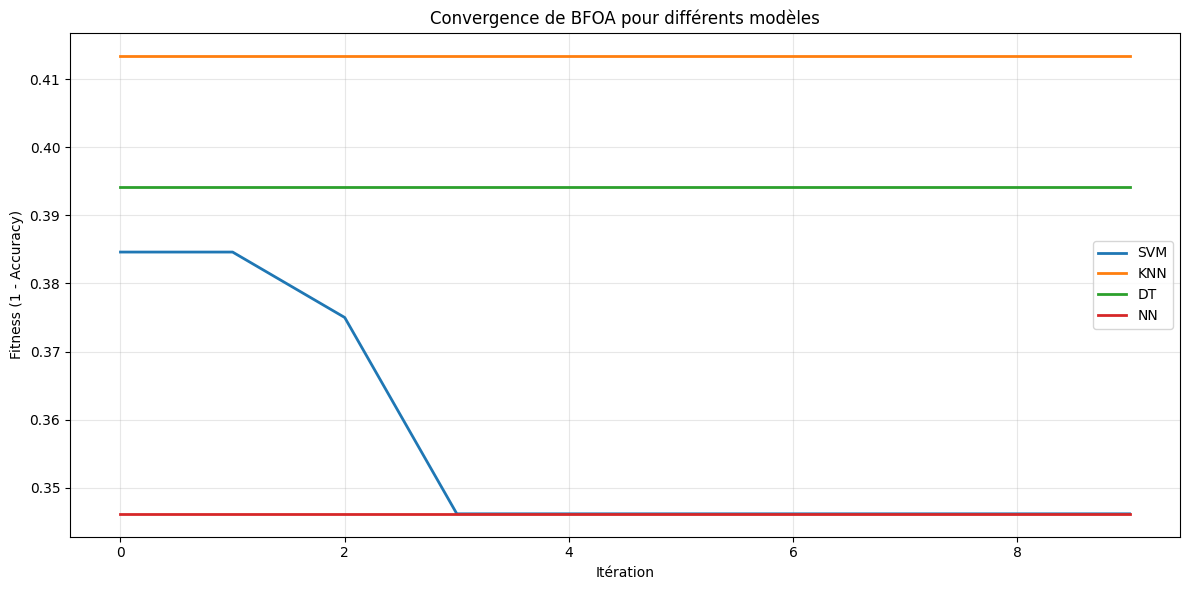

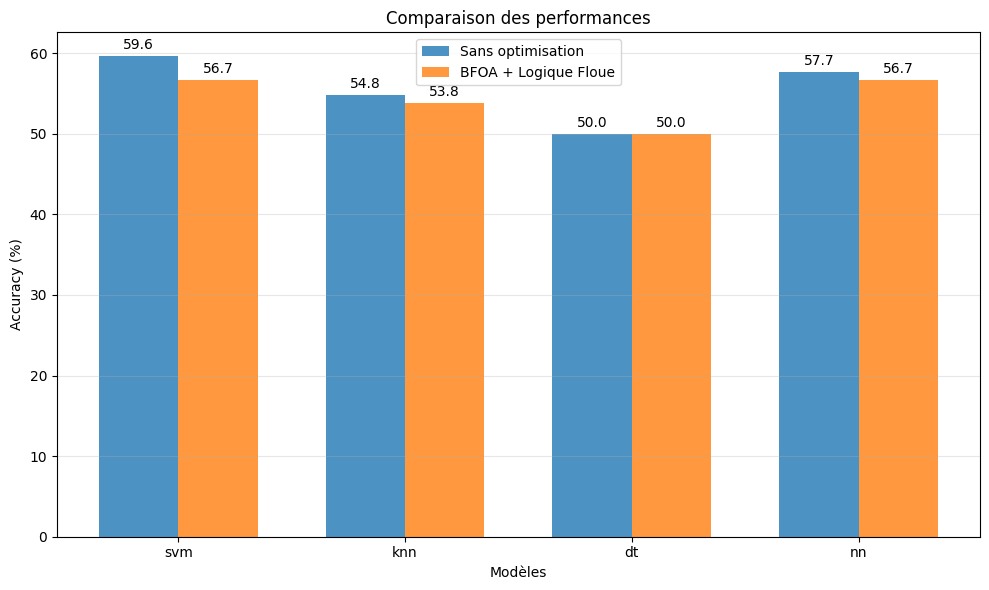

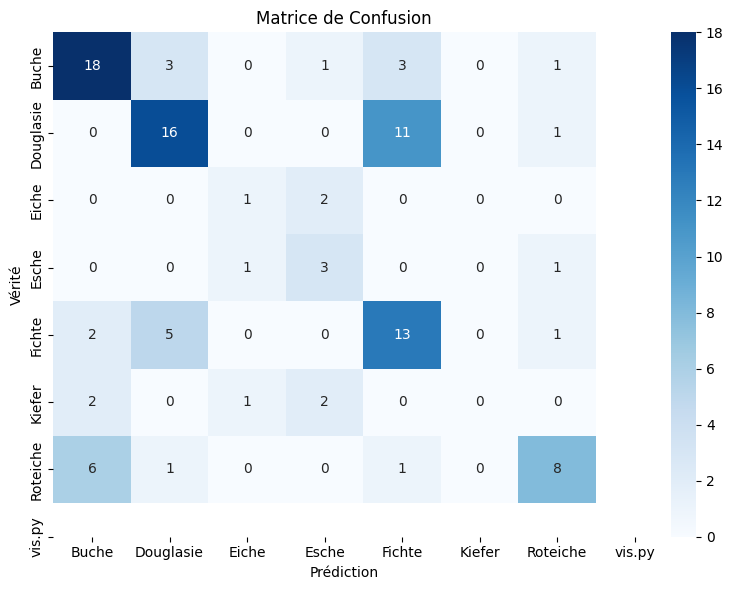

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =====================================================
# 1. PRÉTRAITEMENT
# =====================================================

def subsample_point_cloud(points, n_points=1024):
    """Sous-échantillonne un nuage de points"""
    current_points = len(points)

    if current_points >= n_points:
        indices = np.random.choice(current_points, n_points, replace=False)
        return points[indices]
    else:
        indices = np.random.choice(current_points, n_points, replace=True)
        return points[indices]

def preprocess_data_(data, labels, n_points=512):
    """Version rapide du prétraitement"""
    processed_data = []
    processed_labels = []

    print("Prétraitement rapide des données...")
    for i in tqdm(range(len(data))):
        points = np.asarray(data[i].points)
        if len(points) > 0:
            # Normalisation des points
            points = points - np.mean(points, axis=0)
            points = points / (np.max(np.abs(points)) + 1e-6)

            processed_points = subsample_point_cloud(points, n_points)
            processed_data.append(processed_points)
            processed_labels.append(labels[i])

    return np.array(processed_data), np.array(processed_labels)

# =====================================================
# 2. DGCNN
# =====================================================

class DGCNN(nn.Module):
    """Version simplifiée de DGCNN pour exécution rapide"""
    def __init__(self, k=20, num_classes=7):
        super(DGCNN, self).__init__()
        self.k = k

        # Architecture simplifiée
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 256, 1)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

        self.dropout = nn.Dropout(0.3)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)

    def forward(self, x):
        # x: (batch, points, 3)
        x = x.transpose(2, 1)  # (batch, 3, points)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = F.adaptive_max_pool1d(x, 1).squeeze(2)  # Global max pooling

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        features = F.relu(self.fc2(x))
        x = self.fc3(features)

        return x

    def get_features(self, x):
        """Extraction de features pour les classificateurs"""
        x = x.transpose(2, 1)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = F.adaptive_max_pool1d(x, 1).squeeze(2)

        x = F.relu(self.fc1(x))
        features = F.relu(self.fc2(x))

        return features

# =====================================================
# 3. SYSTÈME FLOU
# =====================================================

class FuzzySystem:
    """Système flou simplifié sans bibliothèque externe"""
    def __init__(self):
        self.rules = [
            # (accuracy_low, conv_slow) -> high adaptation
            (lambda a, c: (1-a) * (1-c), 0.9),
            # (accuracy_medium, conv_medium) -> medium adaptation
            (lambda a, c: 4*a*(1-a) * 4*c*(1-c), 0.5),
            # (accuracy_high, conv_) -> low adaptation
            (lambda a, c: a * c, 0.1),
        ]

    def compute_adaptation_rate(self, accuracy, convergence_rate):
        """Calcul simplifié du taux d'adaptation"""
        total_weight = 0
        weighted_sum = 0

        for rule_func, output in self.rules:
            weight = rule_func(accuracy, convergence_rate)
            total_weight += weight
            weighted_sum += weight * output

        if total_weight > 0:
            return weighted_sum / total_weight
        return 0.5

# =====================================================
# 4. BFOA
# =====================================================

class BFOA:
    """Version simplifiée et rapide de BFOA"""
    def __init__(self, population_size=30, dimensions=2, bounds=None,
                 max_iterations=20, fuzzy_system=None):
        self.population_size = population_size
        self.dimensions = dimensions
        self.bounds = bounds or [(0, 1)] * dimensions
        self.max_iterations = max_iterations
        self.fuzzy_system = fuzzy_system or FuzzySystem()

        # Initialisation
        self.population = np.random.uniform(
            [b[0] for b in self.bounds],
            [b[1] for b in self.bounds],
            (population_size, dimensions)
        )
        self.fitness = np.full(population_size, np.inf)
        self.best_position = None
        self.best_fitness = np.inf
        self.history = []

    def evaluate_population(self, eval_func):
        """Évaluation parallèle de la population"""
        for i in range(self.population_size):
            self.fitness[i] = eval_func(self.population[i])

        # Mise à jour du meilleur
        min_idx = np.argmin(self.fitness)
        if self.fitness[min_idx] < self.best_fitness:
            self.best_fitness = self.fitness[min_idx]
            self.best_position = self.population[min_idx].copy()

        self.history.append(self.best_fitness)

    def optimize(self, eval_func):
        """Optimisation simplifiée"""
        step_size = 0.1

        for iteration in range(self.max_iterations):
            # Évaluation
            self.evaluate_population(eval_func)

            # Chemotaxis simplifié
            for i in range(self.population_size):
                # Mouvement aléatoire
                direction = np.random.randn(self.dimensions)
                direction = direction / (np.linalg.norm(direction) + 1e-8)

                # Nouveau position
                new_pos = self.population[i] + step_size * direction
                new_pos = np.clip(new_pos, [b[0] for b in self.bounds],
                                           [b[1] for b in self.bounds])

                # Évaluation
                new_fitness = eval_func(new_pos)

                # Mise à jour si amélioration
                if new_fitness < self.fitness[i]:
                    self.population[i] = new_pos
                    self.fitness[i] = new_fitness

            # Adaptation du pas avec logique floue
            if len(self.history) > 2:
                accuracy = 1 - self.best_fitness
                convergence = abs(self.history[-2] - self.history[-1])
                step_size = 0.1 * self.fuzzy_system.compute_adaptation_rate(accuracy, convergence)

        return self.best_position, self.best_fitness

# =====================================================
# 5. OPTIMISATION  DES HYPERPARAMÈTRES
# =====================================================

def optimize_hyperparameters_(X_train, y_train, X_val, y_val, model_type='svm'):
    """Optimisation rapide des hyperparamètres"""
    fuzzy_system = FuzzySystem()

    if model_type == 'svm':
        # Bounds réduites pour SVM
        bounds = [(0.1, 10), (0.001, 0.1)]  # C, gamma
        def eval_func(params):
            C, gamma = params
            clf = SVC(C=C, gamma=gamma, kernel='rbf', max_iter=100)
            clf.fit(X_train[:500], y_train[:500])  # Sous-échantillon pour rapidité
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=30, dimensions=2, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'C': best_params[0], 'gamma': best_params[1]}, bfoa.history

    elif model_type == 'knn':
        bounds = [(3, 40)]  # k

        def eval_func(params):
            k = int(params[0])
            clf = KNeighborsClassifier(n_neighbors=k)
            clf.fit(X_train[:500], y_train[:500])
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=30, dimensions=1, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'n_neighbors': int(best_params[0])}, bfoa.history

    elif model_type == 'dt':
        bounds = [(3, 20), (3, 20)]   # max_depth, min_samples_split

        def eval_func(params):
            max_depth, min_samples = int(params[0]), int(params[1])
            clf = DecisionTreeClassifier(max_depth=max_depth,
                                       min_samples_split=min_samples,
                                       random_state=42)
            clf.fit(X_train[:500], y_train[:500])
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=30, dimensions=2, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'max_depth': int(best_params[0]),
                'min_samples_split': int(best_params[1])}, bfoa.history

    elif model_type == 'nn':
        bounds = [(10, 100), (0.001, 0.01)] #hidden_size, learning_rate

        def eval_func(params):
            hidden_size, lr = int(params[0]), params[1]
            clf = MLPClassifier(hidden_layer_sizes=(hidden_size,),
                              learning_rate_init=lr,
                              max_iter=100, random_state=42)
            clf.fit(X_train[:500], y_train[:500])
            acc = accuracy_score(y_val[:200], clf.predict(X_val[:200]))
            return 1 - acc

        bfoa = BFOA(population_size=30, dimensions=2, bounds=bounds,
                         max_iterations=10, fuzzy_system=fuzzy_system)
        best_params, _ = bfoa.optimize(eval_func)
        return {'hidden_layer_sizes': (int(best_params[0]),),
                'learning_rate_init': best_params[1]}, bfoa.history

# =====================================================
# 6. VISUALISATIONS
# =====================================================

def plot_optimization_process(histories, model_names):
    """Visualise le processus d'optimisation BFOA"""
    plt.figure(figsize=(12, 6))

    for i, (history, name) in enumerate(zip(histories, model_names)):
        plt.plot(history, label=f'{name}', linewidth=2)

    plt.xlabel('Itération')
    plt.ylabel('Fitness (1 - Accuracy)')
    plt.title('Convergence de BFOA pour différents modèles')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_fuzzy_system():
    """Visualise le système flou"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Surface de décision du système flou
    accuracy = np.linspace(0, 1, 50)
    convergence = np.linspace(0, 1, 50)
    A, C = np.meshgrid(accuracy, convergence)

    fuzzy_sys = FuzzySystem()
    Z = np.zeros_like(A)

    for i in range(50):
        for j in range(50):
            Z[i, j] = fuzzy_sys.compute_adaptation_rate(A[i, j], C[i, j])

    # Graphique 3D
    contour = ax1.contourf(A, C, Z, levels=20, cmap='viridis')
    ax1.set_xlabel('Accuracy')
    ax1.set_ylabel('Taux de Convergence')
    ax1.set_title('Taux d\'Adaptation (Système Flou)')
    plt.colorbar(contour, ax=ax1)

    # Courbes de membership
    x = np.linspace(0, 1, 100)
    ax2.plot(x, 1-x, label='Low', color='red')
    ax2.plot(x, 4*x*(1-x), label='Medium', color='green')
    ax2.plot(x, x, label='High', color='blue')
    ax2.set_xlabel('Valeur')
    ax2.set_ylabel('Degré d\'appartenance')
    ax2.set_title('Fonctions d\'appartenance simplifiées')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_results_comparison(results_optimized, results_baseline):
    """Compare les résultats optimisés vs baseline"""
    models = list(results_baseline.keys())
    baseline_acc = [results_baseline[m] * 100 for m in models]
    optimized_acc = [results_optimized[m] * 100 for m in models]

    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, baseline_acc, width, label='Sans optimisation', alpha=0.8)
    plt.bar(x + width/2, optimized_acc, width, label='BFOA + Logique Floue', alpha=0.8)

    plt.xlabel('Modèles')
    plt.ylabel('Accuracy (%)')
    plt.title('Comparaison des performances')
    plt.xticks(x, models)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

    # Ajouter les valeurs
    for i, (b, o) in enumerate(zip(baseline_acc, optimized_acc)):
        plt.text(i - width/2, b + 0.5, f'{b:.1f}', ha='center', va='bottom')
        plt.text(i + width/2, o + 0.5, f'{o:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Affiche la matrice de confusion"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité')
    plt.title('Matrice de Confusion')
    plt.tight_layout()
    plt.show()

# =====================================================
# 7. PIPELINE PRINCIPAL SIMPLIFIÉ
# =====================================================

def main(data, labels, class_names):
    """Pipeline principal optimisé pour rapidité"""
    print("=== Pipeline Simplifié BFOA + Logique Floue ===\n")

    # 1. Prétraitement
    print("1. Prétraitement des données...")
    start_time = time.time()
    X, y = preprocess_data_(data, labels, n_points=512)
    print(f"   Temps: {time.time() - start_time:.2f}s")
    print(f"   Shape: {X.shape}")

    # 2. Division des données
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    print(f"\n2. Division: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

    # 3. Entraînement DGCNN simplifié
    print("\n3. Entraînement DGCNN...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Conversion en tenseurs
    train_data = torch.FloatTensor(X_train)
    train_labels = torch.LongTensor(y_train)
    test_data = torch.FloatTensor(X_test)
    test_labels = torch.LongTensor(y_test)

    # DataLoaders
    train_dataset = TensorDataset(train_data, train_labels)
    test_dataset = TensorDataset(test_data, test_labels)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    # Modèle
    model = DGCNN(k=20, num_classes=len(class_names)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Entraînement rapide
    start_time = time.time()
    model.train()
    for epoch in range(20):  # Seulement 20 epochs
        for batch_data, batch_labels in train_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
            optimizer.zero_grad()
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

    print(f"   Temps d'entraînement: {time.time() - start_time:.2f}s")

    # 4. Extraction des features
    print("\n4. Extraction des features DGCNN...")
    model.eval()
    with torch.no_grad():
        train_features = model.get_features(train_data.to(device)).cpu().numpy()
        val_features = model.get_features(torch.FloatTensor(X_val).to(device)).cpu().numpy()
        test_features = model.get_features(test_data.to(device)).cpu().numpy()

    # 5. Optimisation des hyperparamètres
    print("\n5. Optimisation BFOA + Logique Floue...")
    models_to_optimize = ['svm', 'knn', 'dt', 'nn']
    optimized_params = {}
    optimization_histories = []

    for model_name in models_to_optimize:
        print(f"\n   Optimisation {model_name.upper()}...")
        start_time = time.time()
        params, history = optimize_hyperparameters_(
            train_features, y_train, val_features, y_val, model_name
        )
        optimized_params[model_name] = params
        optimization_histories.append(history)
        print(f"   Paramètres: {params}")
        print(f"   Temps: {time.time() - start_time:.2f}s")

    # 6. Entraînement et évaluation finale
    print("\n6. Évaluation finale...")
    results_optimized = {}
    results_baseline = {}

    # Modèles optimisés
    models_opt = {
        'svm': SVC(**optimized_params['svm'], kernel='rbf'),
        'knn': KNeighborsClassifier(**optimized_params['knn']),
        'dt': DecisionTreeClassifier(**optimized_params['dt'], random_state=42),
        'nn': MLPClassifier(**optimized_params['nn'], max_iter=200, random_state=42)
    }

    # Modèles baseline
    models_base = {
        'svm': SVC(kernel='rbf'),
        'knn': KNeighborsClassifier(),
        'dt': DecisionTreeClassifier(random_state=42),
        'nn': MLPClassifier(max_iter=200, random_state=42)
    }

    for name in models_opt:
        # Optimisé
        models_opt[name].fit(train_features, y_train)
        pred_opt = models_opt[name].predict(test_features)
        results_optimized[name] = accuracy_score(y_test, pred_opt)

        # Baseline
        models_base[name].fit(train_features, y_train)
        pred_base = models_base[name].predict(test_features)
        results_baseline[name] = accuracy_score(y_test, pred_base)

    # 7. Affichage des résultats
    print("\n=== RÉSULTATS ===")
    print("\nModèles optimisés (BFOA + Logique Floue):")
    for name, acc in results_optimized.items():
        print(f"   {name.upper()}: {acc*100:.2f}%")

    print("\nModèles baseline:")
    for name, acc in results_baseline.items():
        print(f"   {name.upper()}: {acc*100:.2f}%")

    print("\nAmélioration:")
    for name in results_optimized:
        improvement = (results_optimized[name] - results_baseline[name]) / results_baseline[name] * 100
        print(f"   {name.upper()}: {improvement:+.2f}%")

    # 8. Visualisations
    print("\n8. Génération des visualisations...")

    # Système flou
    plot_fuzzy_system()

    # Processus d'optimisation
    plot_optimization_process(optimization_histories, [m.upper() for m in models_to_optimize])

    # Comparaison des résultats
    plot_results_comparison(results_optimized, results_baseline)

    # Matrice de confusion pour le meilleur modèle
    best_model_name = max(results_optimized, key=results_optimized.get)
    best_predictions = models_opt[best_model_name].predict(test_features)
    plot_confusion_matrix(y_test, best_predictions, class_names)

    return results_optimized, results_baseline, optimized_params

# =====================================================
# UTILISATION
# =====================================================

if __name__ == "__main__":
    # Exemple d'utilisation
    print("Pour exécuter le pipeline:")
    results_opt, results_base, params = main(data, labels, class_names)
